In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed= 42

In [38]:
def preprocess_data(data):
    df= data.copy()

    df.drop(columns=['ID'], inplace= True)

    return df

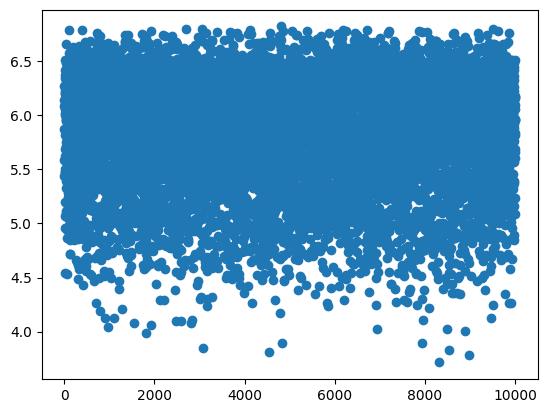

In [39]:
train_df= pd.read_csv("train_data.csv")
test_df= pd.read_csv("test_data.csv")

X_train= preprocess_data(train_df.drop(columns=['deliver_time']))
y_train= np.log1p(train_df['deliver_time'])

X_test= preprocess_data(test_df)

plt.scatter(train_df['ID'], y_train)
plt.show()

In [40]:
# Subtask 1
answer1= pd.DataFrame({
    'subtaskID': 1,
    'datapointID': 1,
    'answer': [len(test_df[
        (test_df['City A'] == 'Barlad') &
        (test_df['Weather'] == 'Fog')
    ])]
})

answer1.head()

,subtaskID,datapointID,answer
0,1,1,15


In [41]:
# Subtask 2
from catboost import CatBoostRegressor

cat_cols= X_train.select_dtypes(include=['object', 'str']).columns.to_list()

model= CatBoostRegressor(
    iterations=5000,
    learning_rate=0.03,
    depth=6,
    cat_features= cat_cols,
    early_stopping_rounds= 200,
    random_state= seed
)

model.fit(X_train, y_train, verbose=200)

0:	learn: 0.4876010	total: 5.41ms	remaining: 27.1s
200:	learn: 0.0216360	total: 809ms	remaining: 19.4s
400:	learn: 0.0138460	total: 1.59s	remaining: 18.2s
600:	learn: 0.0116582	total: 2.4s	remaining: 17.6s
800:	learn: 0.0106740	total: 3.22s	remaining: 16.9s
1000:	learn: 0.0100396	total: 4.01s	remaining: 16.1s
1200:	learn: 0.0095347	total: 4.74s	remaining: 15s
1400:	learn: 0.0090966	total: 5.51s	remaining: 14.2s
1600:	learn: 0.0087140	total: 6.25s	remaining: 13.3s
1800:	learn: 0.0083927	total: 6.99s	remaining: 12.4s
2000:	learn: 0.0081275	total: 7.74s	remaining: 11.6s
2200:	learn: 0.0078915	total: 8.52s	remaining: 10.9s
2400:	learn: 0.0076949	total: 9.26s	remaining: 10s
2600:	learn: 0.0075120	total: 10s	remaining: 9.24s
2800:	learn: 0.0073287	total: 10.8s	remaining: 8.47s
3000:	learn: 0.0071769	total: 11.5s	remaining: 7.7s
3200:	learn: 0.0070188	total: 12.3s	remaining: 6.92s
3400:	learn: 0.0068649	total: 13.1s	remaining: 6.15s
3600:	learn: 0.0067279	total: 13.8s	remaining: 5.37s
3800:	l

CatBoostRegressor(cat_features=['City A', 'City B', 'Weather'], depth=6, early_stopping_rounds=200, iterations=5000, learning_rate=0.03, loss_function='RMSE', random_state=42)

In [42]:
predictions= np.expm1(model.predict(X_test))

answer2= pd.DataFrame({
    'subtaskID': 2,
    'datapointID': test_df['ID'],
    'answer': predictions
})

answer2.head()

,subtaskID,datapointID,answer
0,2,10001,387.123910
1,2,10002,242.660461
2,2,10003,480.034159
3,2,10004,248.949224
4,2,10005,337.551791


In [43]:
answer= pd.concat([answer1, answer2])

answer.to_csv("submission.csv", index= False)